# Pew surveys dataset: basic preprocessing and first look

In this project we compare Trump-related discussion on Reddit with US public opinion. For public opinion we use Pew Research Center surveys. The file `pew_surveys.csv` was made from 9 Pew survey files (the raw files were studied in `pew_raw_exploration.ipynb`, and combined by `scripts/combine_pew_surveys.py`).

## 0. Setup

In [1]:
from pathlib import Path
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "survey" / "pew_surveys.csv"
CLEAN_PATH = ROOT / "data" / "cleaned" / "pew_surveys_clean.csv"
print("Input file:", DATA_PATH)

Input file: D:\могилянка\обсус\reddit_project\data\processed\survey\pew_surveys.csv


## 1. Load the data

In [2]:
pew = pd.read_csv(DATA_PATH, dtype={"orig_id": str})
pew.head(10)

,wave_id,source_family,orig_id,interview_date,mode,trump_approval,approval_strength,party_lean,ideology,gender,age,age_group,education,weight_raw,weight_norm
0,Feb17,phone_rdd,100008,2017-02-10,phone_rdd,disapprove,very_strongly,dem_lean,liberal,woman,80.0,65+,college_grad_plus,1.733333,0.536974
1,Feb17,phone_rdd,100019,2017-02-12,phone_rdd,disapprove,very_strongly,dem_lean,moderate,woman,70.0,65+,college_grad_plus,1.500000,0.464689
2,Feb17,phone_rdd,100020,2017-02-12,phone_rdd,disapprove,very_strongly,dem_lean,liberal,woman,69.0,65+,college_grad_plus,1.533333,0.475015
3,Feb17,phone_rdd,100021,2017-02-07,phone_rdd,approve,not_so_strongly,rep_lean,conservative,man,50.0,50-64,hs_or_less,5.866667,1.817450
4,Feb17,phone_rdd,100024,2017-02-07,phone_rdd,disapprove,very_strongly,dem_lean,liberal,woman,70.0,65+,college_grad_plus,1.700000,0.526647
5,Feb17,phone_rdd,100026,2017-02-07,phone_rdd,disapprove,very_strongly,dem_lean,moderate,man,78.0,65+,college_grad_plus,1.033333,0.320119
6,Feb17,phone_rdd,100027,2017-02-07,phone_rdd,disapprove,not_so_strongly,rep_lean,conservative,woman,89.0,65+,some_college,2.200000,0.681544
7,Feb17,phone_rdd,100030,2017-02-07,phone_rdd,approve,very_strongly,rep_lean,conservative,woman,92.0,65+,some_college,1.600000,0.495668
8,Feb17,phone_rdd,100037,2017-02-07,phone_rdd,approve,very_strongly,other_dk,moderate,woman,54.0,50-64,some_college,5.000000,1.548963
9,Feb17,phone_rdd,100039,2017-02-07,phone_rdd,disapprove,very_strongly,dem_lean,moderate,woman,58.0,50-64,some_college,4.333333,1.342435


In [3]:
pew.tail(5)

,wave_id,source_family,orig_id,interview_date,mode,trump_approval,approval_strength,party_lean,ideology,gender,age,age_group,education,weight_raw,weight_norm
20652,W167,atp,202400022648,2025-04-08,atp_web,disapprove,very_strongly,dem_lean,very_liberal,woman,NaN,18-29,college_grad_plus,0.178533,0.178533
20653,W167,atp,202400022653,2025-04-09,atp_web,approve,very_strongly,rep_lean,moderate,man,NaN,18-29,college_grad_plus,0.209793,0.209793
20654,W167,atp,202400022662,2025-04-08,atp_web,approve,very_strongly,rep_lean,moderate,woman,NaN,18-29,college_grad_plus,1.276306,1.276306
20655,W167,atp,202400022682,2025-04-08,atp_web,approve,not_so_strongly,dem_lean,moderate,woman,NaN,30-49,some_college,1.019243,1.019243
20656,W167,atp,202400022689,2025-04-09,atp_web,disapprove,very_strongly,rep_lean,liberal,man,NaN,30-49,hs_or_less,1.365590,1.365590


In [4]:
print("Shape (rows, columns):", pew.shape)
print("File size, MB:", round(DATA_PATH.stat().st_size / 1024**2, 2))

Shape (rows, columns): (20657, 15)
File size, MB: 2.93


## 2. What the columns are

One row is one respondent in one survey wave

| Column | Meaning |
|---|---|
| `wave_id` | which survey (e.g. `Feb17` = February 2017, `W161` = American Trends Panel wave 161) |
| `source_family` | type of survey: `phone_rdd` (telephone, 2017-2018) or `atp` (online panel, 2025) |
| `orig_id` | respondent ID inside the survey |
| `interview_date` | date of the interview |
| `mode` | how the person was interviewed: `phone_rdd`, `atp_web`, `atp_phone` |
| `trump_approval` | main variable: `approve`, `disapprove` or `dk` (don't know / refused) |
| `approval_strength` | follow-up: `very_strongly`, `not_so_strongly` or `dk` |
| `party_lean` | `rep_lean` / `dem_lean` / `other_dk` |
| `ideology` | from `very_conservative` to `very_liberal` |
| `gender` | `man`, `woman`, `other` |
| `age` | exact age (only in the telephone surveys) |
| `age_group` | `18-29`, `30-49`, `50-64`, `65+` |
| `education` | `hs_or_less`, `some_college`, `college_grad_plus` |
| `weight_raw` | survey weight|
| `weight_norm` | the same weight rescaled to mean 1 inside each wave |

## 3. Data types

In [5]:
pew.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20657 entries, 0 to 20656
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   wave_id            20657 non-null  object 
 1   source_family      20657 non-null  object 
 2   orig_id            20657 non-null  object 
 3   interview_date     20657 non-null  object 
 4   mode               20657 non-null  object 
 5   trump_approval     20657 non-null  object 
 6   approval_strength  16624 non-null  object 
 7   party_lean         20657 non-null  object 
 8   ideology           20098 non-null  object 
 9   gender             20629 non-null  object 
 10  age                11771 non-null  float64
 11  age_group          20407 non-null  object 
 12  education          20553 non-null  object 
 13  weight_raw         20657 non-null  float64
 14  weight_norm        20657 non-null  float64
dtypes: float64(3), object(12)
memory usage: 2.4+ MB


In [6]:
memory_before = pew.memory_usage(deep=True).sum() / 1024**2

pew["interview_date"] = pd.to_datetime(pew["interview_date"])

category_columns = ["wave_id", "source_family", "mode", "trump_approval", "approval_strength",
                    "party_lean", "ideology", "gender", "age_group", "education"]
for col in category_columns:
    pew[col] = pew[col].astype("category")

memory_after = pew.memory_usage(deep=True).sum() / 1024**2
print("Memory before, MB:", round(memory_before, 2))
print("Memory after, MB:", round(memory_after, 2))
pew.dtypes.to_frame("type")

Memory before, MB: 13.89
Memory after, MB: 1.96


,type
wave_id,category
source_family,category
orig_id,object
interview_date,datetime64[ns]
mode,category
trump_approval,category
approval_strength,category
party_lean,category
ideology,category
gender,category


## 4. Missing values

In [7]:
missing = pd.DataFrame({"missing": pew.isna().sum(), "percent": (pew.isna().mean() * 100).round(1)})
missing

,missing,percent
wave_id,0,0.0
source_family,0,0.0
orig_id,0,0.0
interview_date,0,0.0
mode,0,0.0
trump_approval,0,0.0
approval_strength,4033,19.5
party_lean,0,0.0
ideology,559,2.7
gender,28,0.1


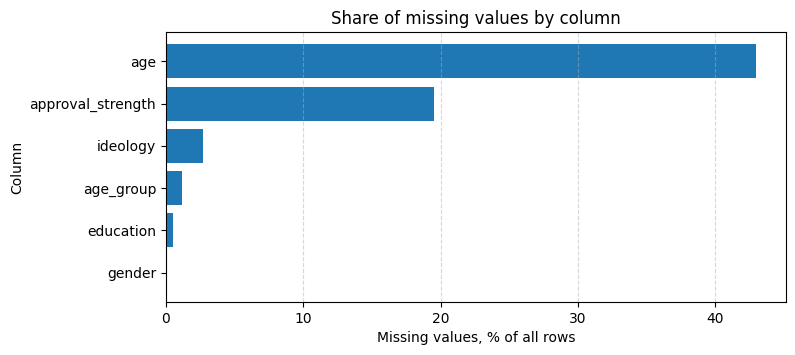

In [8]:
to_plot = missing[missing["missing"] > 0].sort_values("percent")

plt.figure(figsize=(8, 3.5))
plt.barh(to_plot.index, to_plot["percent"])
plt.title("Share of missing values by column")
plt.xlabel("Missing values, % of all rows")
plt.ylabel("Column")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [9]:
missing_by_wave = pew.drop(columns="wave_id").isna().groupby(pew["wave_id"], observed=True).mean() * 100
missing_by_wave = missing_by_wave[["approval_strength", "ideology", "gender", "age", "age_group", "education"]]
missing_by_wave.round(1)

,approval_strength,ideology,gender,age,age_group,education
wave_id,,,,,,
Apr17,5.1,2.4,0.0,1.4,1.4,0.5
Feb17,4.7,2.9,0.0,0.9,0.9,0.7
Jan18,5.7,4.3,0.0,1.9,1.9,0.5
Jun18,100.0,3.7,0.0,1.7,1.7,0.7
Mar18,100.0,2.3,0.0,2.5,2.5,1.0
May18,5.7,5.2,0.0,2.7,2.7,1.1
Typology17,5.4,2.4,0.0,1.4,1.4,0.4
W161,1.7,1.9,0.3,100.0,0.4,0.3
W167,0.8,2.0,0.3,100.0,0.5,0.2


The missing values have clear reasons, so we do not fill them:
- `approval_strength` is 100% missing in `Mar18` and `Jun18`, because there was no such follow-up question in these surveys). In other waves it is missing for people who answered "don't know" to the main question.
- `age` is missing in all online-panel waves (`W161`, `W167`), because there only age groups are published.
- `ideology`, `gender`, `age_group`, `education` are missing in a few percent of cases or less (at most about 5% for ideology), when the person refused to answer.

## 5. Duplicates

In [10]:
print("Fully identical rows:", pew.duplicated().sum())
print("Same respondent twice in the same wave:", pew.duplicated(subset=["wave_id", "orig_id"]).sum())

rows_before = len(pew)
pew = pew.drop_duplicates()
pew = pew.drop_duplicates(subset=["wave_id", "orig_id"])

Fully identical rows: 0
Same respondent twice in the same wave: 0


No duplicates. The same person can be in `W161` and `W167` (online panel), but these are two answers at two moments of time, so we keep both:

In [11]:
ids_w161 = set(pew.loc[pew["wave_id"] == "W161", "orig_id"])
ids_w167 = set(pew.loc[pew["wave_id"] == "W167", "orig_id"])
print("In W161:", len(ids_w161), "\nin W167:", len(ids_w167), "\nin both:", len(ids_w161 & ids_w167))

In W161: 5086 
in W167: 3589 
in both: 2423


## 6. Checking the values

**Categories.**

In [12]:
for col in category_columns:
    print(col, ":", list(pew[col].cat.categories))

wave_id : ['Apr17', 'Feb17', 'Jan18', 'Jun18', 'Mar18', 'May18', 'Typology17', 'W161', 'W167']
source_family : ['atp', 'phone_rdd']
mode : ['atp_phone', 'atp_web', 'phone_rdd']
trump_approval : ['approve', 'disapprove', 'dk']
approval_strength : ['dk', 'not_so_strongly', 'very_strongly']
party_lean : ['dem_lean', 'other_dk', 'rep_lean']
ideology : ['conservative', 'liberal', 'moderate', 'very_conservative', 'very_liberal']
gender : ['man', 'other', 'woman']
age_group : ['18-29', '30-49', '50-64', '65+']
education : ['college_grad_plus', 'hs_or_less', 'some_college']


**Numbers.**

In [13]:
pew[["age", "weight_raw", "weight_norm"]].describe().round(2)

,age,weight_raw,weight_norm
count,11771.00,20657.00,20657.00
mean,51.46,1.56,1.00
std,18.04,1.42,0.58
min,18.00,0.13,0.13
25%,36.00,0.76,0.58
50%,53.00,1.07,0.89
75%,65.00,1.82,1.23
max,97.00,8.16,3.50


Age is from 18 to 97, all weights are positive. The weights are different for different respondents, which is normal for survey weights.

In [14]:
weights = pew.groupby("wave_id", observed=True)["weight_norm"].agg(["min", "mean", "max"]).round(2)
weights = weights.loc[pew["wave_id"].cat.categories]
weights

,min,mean,max
Apr17,0.35,1.0,2.32
Feb17,0.31,1.0,2.38
Jan18,0.30,1.0,2.38
Jun18,0.31,1.0,2.43
Mar18,0.23,1.0,2.94
May18,0.34,1.0,2.53
Typology17,0.32,1.0,2.61
W161,0.16,1.0,3.50
W167,0.13,1.0,2.72


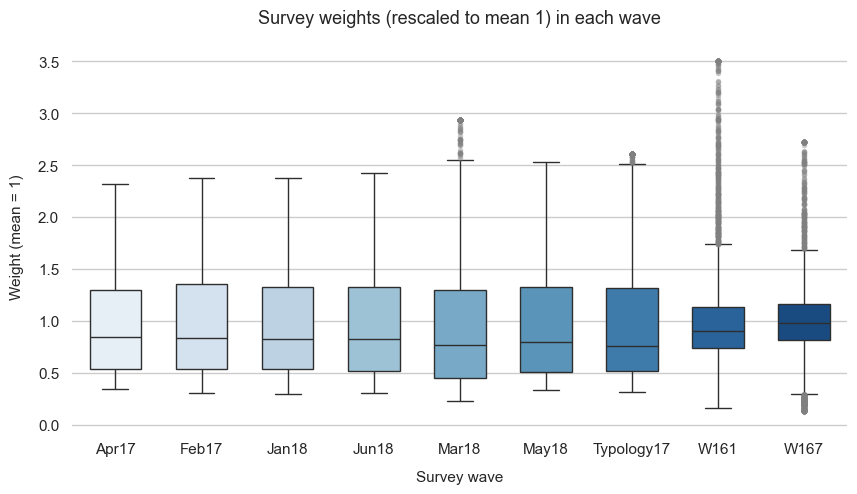

In [15]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=pew, 
    x="wave_id", 
    y="weight_norm", 
    hue="wave_id",  
    legend=False,
    palette="Blues",          
    fliersize=4,              
    flierprops={"alpha": 0.4, "markerfacecolor": "gray", "markeredgecolor": "none"}, 
    width=0.6                 
)


sns.despine(left=True, bottom=True)
plt.title("Survey weights (rescaled to mean 1) in each wave", fontsize=13, pad=15)
plt.xlabel("Survey wave", fontsize=11, labelpad=10)
plt.ylabel("Weight (mean = 1)", fontsize=11, labelpad=10)
plt.show()

Inside each wave the weights go from about 0.1 to 3.5 times the average weight, so there are no extreme outliers. We keep all of them. The weights are part of the survey design and are needed for correct estimates.

**Dates.**

In [16]:
dates = pew.groupby("wave_id", observed=True)["interview_date"].agg(["min", "max", "count"])
dates["days"] = (dates["max"] - dates["min"]).dt.days
dates

,min,max,count,days
wave_id,,,,
Apr17,2017-04-05,2017-04-11,1501,6
Feb17,2017-02-07,2017-02-12,1503,5
Jan18,2018-01-10,2018-01-16,1503,6
Jun18,2018-06-05,2018-06-12,2002,7
Mar18,2018-03-07,2018-03-13,1466,6
May18,2018-04-25,2018-05-01,1503,6
Typology17,2017-06-08,2017-06-18,2504,10
W161,2025-01-27,2025-02-02,5086,6
W167,2025-04-07,2025-04-13,3589,6


Each wave is a short period of 5-10 days (the longest is `Typology17`, 8-18 June 2017)

**Logical checks.** 

In [17]:
expected_group = pd.cut(pew["age"], bins=[17, 29, 49, 64, 120], labels=["18-29", "30-49", "50-64", "65+"])
with_age = pew["age"].notna()
wrong = (expected_group[with_age].astype(str) != pew.loc[with_age, "age_group"].astype(str)).sum()
print("Rows where age and age_group disagree:", wrong)

pd.crosstab(pew["trump_approval"], pew["approval_strength"].astype(object).fillna("missing"))

Rows where age and age_group disagree: 0


approval_strength,dk,missing,not_so_strongly,very_strongly
trump_approval,,,,
approve,144,1418,1456,5397
disapprove,104,1868,1535,7988
dk,0,747,0,0


Both checks are fine. Age and age group agree everywhere, and people who answered "don't know" to the main question have no follow-up answer.

## 7. Small cleaning and helper columns

The data is already clean, so we only add three simple columns which we will need to line up the surveys with the Reddit periods: year, month and which presidency the survey belongs to.

In [18]:
pew["year"] = pew["interview_date"].dt.year
pew["month"] = pew["interview_date"].dt.month
pew["presidency"] = (pew["year"] >= 2025).map({False: "first", True: "second"})

pew[["wave_id", "interview_date", "year", "month", "presidency"]].drop_duplicates("wave_id")

,wave_id,interview_date,year,month,presidency
0,Feb17,2017-02-10,2017,2,first
1503,Apr17,2017-04-05,2017,4,first
3004,Typology17,2017-06-14,2017,6,first
5508,Jan18,2018-01-10,2018,1,first
7011,Mar18,2018-03-08,2018,3,first
8477,May18,2018-04-25,2018,4,first
9980,Jun18,2018-06-05,2018,6,first
11982,W161,2025-01-28,2025,1,second
17068,W167,2025-04-08,2025,4,second


## 8. Saving the prepared data

In [19]:
pew.to_csv(CLEAN_PATH, index=False)
print("Saved:", CLEAN_PATH)

Saved: D:\могилянка\обсус\reddit_project\data\cleaned\pew_surveys_clean.csv


## 9. Basic metrics

In [20]:
clean = pd.read_csv(CLEAN_PATH, dtype={"orig_id": str}, parse_dates=["interview_date"])
clean.head(10)

,wave_id,source_family,orig_id,interview_date,mode,trump_approval,approval_strength,party_lean,ideology,gender,age,age_group,education,weight_raw,weight_norm,year,month,presidency
0,Feb17,phone_rdd,100008,2017-02-10,phone_rdd,disapprove,very_strongly,dem_lean,liberal,woman,80.0,65+,college_grad_plus,1.733333,0.536974,2017,2,first
1,Feb17,phone_rdd,100019,2017-02-12,phone_rdd,disapprove,very_strongly,dem_lean,moderate,woman,70.0,65+,college_grad_plus,1.500000,0.464689,2017,2,first
2,Feb17,phone_rdd,100020,2017-02-12,phone_rdd,disapprove,very_strongly,dem_lean,liberal,woman,69.0,65+,college_grad_plus,1.533333,0.475015,2017,2,first
3,Feb17,phone_rdd,100021,2017-02-07,phone_rdd,approve,not_so_strongly,rep_lean,conservative,man,50.0,50-64,hs_or_less,5.866667,1.817450,2017,2,first
4,Feb17,phone_rdd,100024,2017-02-07,phone_rdd,disapprove,very_strongly,dem_lean,liberal,woman,70.0,65+,college_grad_plus,1.700000,0.526647,2017,2,first
5,Feb17,phone_rdd,100026,2017-02-07,phone_rdd,disapprove,very_strongly,dem_lean,moderate,man,78.0,65+,college_grad_plus,1.033333,0.320119,2017,2,first
6,Feb17,phone_rdd,100027,2017-02-07,phone_rdd,disapprove,not_so_strongly,rep_lean,conservative,woman,89.0,65+,some_college,2.200000,0.681544,2017,2,first
7,Feb17,phone_rdd,100030,2017-02-07,phone_rdd,approve,very_strongly,rep_lean,conservative,woman,92.0,65+,some_college,1.600000,0.495668,2017,2,first
8,Feb17,phone_rdd,100037,2017-02-07,phone_rdd,approve,very_strongly,other_dk,moderate,woman,54.0,50-64,some_college,5.000000,1.548963,2017,2,first
9,Feb17,phone_rdd,100039,2017-02-07,phone_rdd,disapprove,very_strongly,dem_lean,moderate,woman,58.0,50-64,some_college,4.333333,1.342435,2017,2,first


**Size and number of rows.**

In [21]:
metrics = pd.DataFrame({
    "value": [round(CLEAN_PATH.stat().st_size / 1024**2, 2), len(clean), clean.shape[1], clean["wave_id"].nunique(),
              str(clean["interview_date"].min().date()), str(clean["interview_date"].max().date())]
}, index=["File size, MB", "Number of rows (respondents)", "Number of columns", "Number of survey waves",
          "First interview date", "Last interview date"])
metrics

,value
"File size, MB",3.18
Number of rows (respondents),20657
Number of columns,18
Number of survey waves,9
First interview date,2017-02-07
Last interview date,2025-04-13


**Breakdown by type.**

In [22]:
by_type = clean["source_family"].value_counts().to_frame("rows")
by_type["percent"] = (by_type["rows"] / len(clean) * 100).round(1)
by_type

,rows,percent
source_family,,
phone_rdd,11982,58.0
atp,8675,42.0


In [23]:
by_mode = clean["mode"].value_counts().to_frame("rows")
by_mode["percent"] = (by_mode["rows"] / len(clean) * 100).round(1)
by_mode

,rows,percent
mode,,
phone_rdd,11982,58.0
atp_web,8358,40.5
atp_phone,317,1.5


**Breakdown by survey wave.**

In [24]:
wave_order = ["Feb17", "Apr17", "Typology17", "Jan18", "Mar18", "May18", "Jun18", "W161", "W167"]

by_wave = clean.groupby("wave_id").agg(type=("source_family", "first"), rows=("orig_id", "size"),
                                       first_date=("interview_date", "min"), last_date=("interview_date", "max"))
by_wave = by_wave.loc[wave_order]
by_wave["first_date"] = by_wave["first_date"].dt.date
by_wave["last_date"] = by_wave["last_date"].dt.date
by_wave

,type,rows,first_date,last_date
wave_id,,,,
Feb17,phone_rdd,1503,2017-02-07,2017-02-12
Apr17,phone_rdd,1501,2017-04-05,2017-04-11
Typology17,phone_rdd,2504,2017-06-08,2017-06-18
Jan18,phone_rdd,1503,2018-01-10,2018-01-16
Mar18,phone_rdd,1466,2018-03-07,2018-03-13
May18,phone_rdd,1503,2018-04-25,2018-05-01
Jun18,phone_rdd,2002,2018-06-05,2018-06-12
W161,atp,5086,2025-01-27,2025-02-02
W167,atp,3589,2025-04-07,2025-04-13


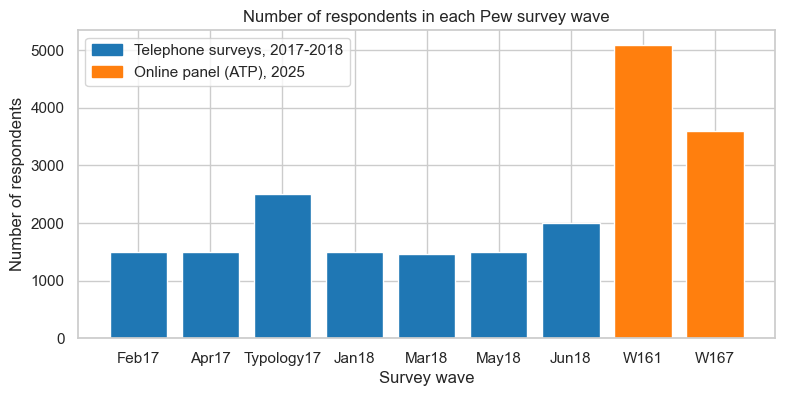

In [25]:
counts = clean["wave_id"].value_counts().reindex(wave_order)
colors = ["tab:orange" if w in ["W161", "W167"] else "tab:blue" for w in wave_order]

plt.figure(figsize=(9, 4))
plt.bar(counts.index, counts.values, color=colors)
plt.title("Number of respondents in each Pew survey wave")
plt.xlabel("Survey wave")
plt.ylabel("Number of respondents")
plt.legend(handles=[Patch(color="tab:blue", label="Telephone surveys, 2017-2018"),
                    Patch(color="tab:orange", label="Online panel (ATP), 2025")])
plt.show()

**Frequency overview of the categories**:

In [26]:
from IPython.display import display, HTML

html_str = '<div style="display: flex; flex-wrap: wrap; gap: 20px;">'

for col in ["trump_approval", "approval_strength", "party_lean", "ideology", "gender", "age_group", "education"]:
    table = clean[col].value_counts(dropna=False).to_frame("rows")
    table["percent"] = (table["rows"] / len(clean) * 100).round(1)
    
    table_html = table.to_html(classes="table table-striped")
    html_str += f'<div style="flex: 1; min-width: 250px;"><h3>{col}</h3>{table_html}</div>'

html_str += '</div>'
display(HTML(html_str))

,rows,percent
trump_approval,,
disapprove,11495,55.6
approve,8415,40.7
dk,747,3.6
,rows,percent
approval_strength,,
very_strongly,13385,64.8
NaN,4033,19.5
not_so_strongly,2991,14.5
dk,248,1.2


these are counts of respondents in the sample. To estimate shares for the whole US population the weights (`weight_raw`) must be used, separately inside each wave.